<a href="https://colab.research.google.com/github/imrs12/practical/blob/main/dl3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

[INFO] training...
[INFO] epoch=1, loss=10.9639582
[INFO] epoch=5, loss=0.1421639
[INFO] epoch=10, loss=0.0876145
[INFO] epoch=15, loss=0.0685265
[INFO] epoch=20, loss=0.0576176
[INFO] epoch=25, loss=0.0503675
[INFO] epoch=30, loss=0.0451162
[INFO] epoch=35, loss=0.0410939
[INFO] epoch=40, loss=0.0378893
[INFO] epoch=45, loss=0.0352606
[INFO] epoch=50, loss=0.0330553
[INFO] epoch=55, loss=0.0311717
[INFO] epoch=60, loss=0.0295394
[INFO] epoch=65, loss=0.0281077
[INFO] epoch=70, loss=0.0268390
[INFO] epoch=75, loss=0.0257050
[INFO] epoch=80, loss=0.0246838
[INFO] epoch=85, loss=0.0237580
[INFO] epoch=90, loss=0.0229138
[INFO] epoch=95, loss=0.0221402
[INFO] epoch=100, loss=0.0214279
[INFO] evaluating...
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       250
           1       1.00      1.00      1.00       250

    accuracy                           1.00       500
   macro avg       1.00      1.00      1.00       500
weighted avg    

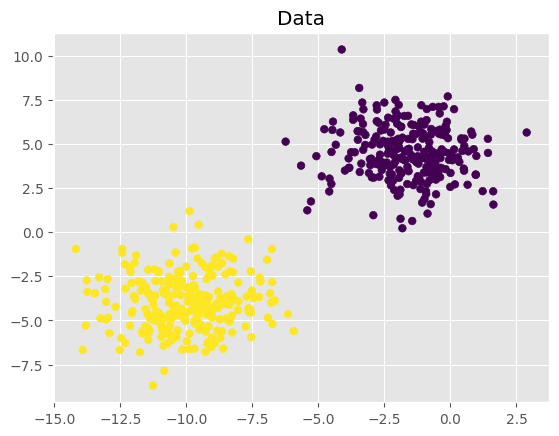

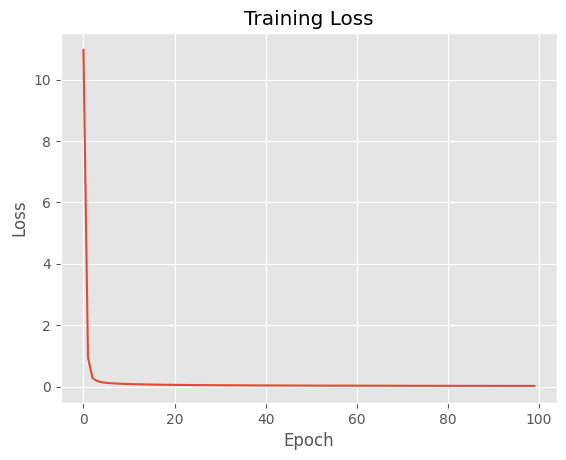

In [1]:
# import the necessary packages
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt
import numpy as np
import argparse
import sys

sys.argv = ['']
del sys


# sigmoid activation function
def sigmoid_activation(x):
    return 1 / (1 + np.exp(-x))


# derivative of sigmoid (assuming input already passed through sigmoid)
def sigmoid_deriv(x):
    return x * (1 - x)


# prediction function
def predict(X, W):
    preds = sigmoid_activation(X.dot(W))
    preds[preds <= 0.5] = 0
    preds[preds > 0.5] = 1
    return preds


# mini-batch generator
def next_batch(X, y, batchSize):
    for i in np.arange(0, X.shape[0], batchSize):
        yield (X[i:i + batchSize], y[i:i + batchSize])


# argument parser
ap = argparse.ArgumentParser()
ap.add_argument("-e", "--epochs", type=float, default=100,
                help="number of epochs")
ap.add_argument("-a", "--alpha", type=float, default=0.01,
                help="learning rate")
ap.add_argument("-b", "--batch-size", type=int, default=32,
                help="size of SGD mini-batches")

args = vars(ap.parse_args())


# generate dataset
X, y = make_blobs(n_samples=1000, n_features=2,
                  centers=2, cluster_std=1.5, random_state=1)

y = y.reshape((y.shape[0], 1))

# add bias column
X = np.c_[X, np.ones((X.shape[0]))]

# train-test split
(trainX, testX, trainY, testY) = train_test_split(
    X, y, test_size=0.5, random_state=42
)

# initialize weights and loss list
print("[INFO] training...")
W = np.random.randn(X.shape[1], 1)
losses = []

# training loop
for epoch in np.arange(0, args["epochs"]):
    epochLoss = []

    for (batchX, batchY) in next_batch(trainX, trainY, args["batch_size"]):
        # forward pass
        preds = sigmoid_activation(batchX.dot(W))

        # compute error
        error = preds - batchY
        epochLoss.append(np.sum(error ** 2))

        # backpropagation
        d = error * sigmoid_deriv(preds)
        gradient = batchX.T.dot(d)

        # update weights
        W += -args["alpha"] * gradient

    # average loss
    loss = np.average(epochLoss)
    losses.append(loss)

    # display progress
    if epoch == 0 or (epoch + 1) % 5 == 0:
        print("[INFO] epoch={}, loss={:.7f}".format(int(epoch + 1), loss))


# evaluation
print("[INFO] evaluating...")
preds = predict(testX, W)
print(classification_report(testY, preds))


# plot test data
plt.style.use("ggplot")
fig, ax = plt.subplots()
ax.set_title("Data")
ax.scatter(testX[:, 0], testX[:, 1],
           marker="o", c=testY[:, 0], s=30)

# plot training loss
fig, ax = plt.subplots()
ax.plot(np.arange(0, len(losses)), losses)
ax.set_title("Training Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")

plt.show()

SGD is a popular optimization algorithm used to train neural networks. The main idea behind SGD is to iteratively adjust the model parameters in order to minimize a cost function (also called a loss function) that measures the difference between the predicted output of the network and the actual output. In SGD, the cost function is computed for a small random subset of the training data (known as a mini-batch), and the model parameters are adjusted based on the gradient of the cost function with respect to the parameters. This process is repeated multiple times, with different mini-batches of the data being used each time, until the cost function is minimized. One advantage of using SGD over other optimization algorithms is that it is computationally efficient, especially when dealing with large datasets. By computing the cost function on small subsets of the data, the gradient can be estimated more quickly and the model can be updated more frequently. There are also several variants of SGD, including momentum, Adagrad, RMSprop, and Adam, that are commonly used in deep learning. These variants help to overcome some of the limitations of standard SGD, such as slow convergence and difficulty in choosing an appropriate learning rate.